# **Análise da Influência Geográfica nos Preços de Imóveis** 💰

#**🧠 Problema**

#**"Quais são os principais fatores que influenciam o preço dos imóveis por estados e como prever o preço justo de uma casa com base em suas características?"**

# **Equipe:**

*  Felipe Santos
*  Ivson Santana
*  Larrisa Mercês
*  Maria Vitória
*  Pablo Riquelme
*  Raimundo Dantas
*  Sanderson Rhawan

## Importação das principais bibliotecas

In [1]:
!pip install pandas scikit-learn matplotlib seaborn
!pip install ydata-profiling
!pip install pymongo requests

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.1/400.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.7 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=bebe68e24a6a63d80e6960a204cad2b78197edce398beafab87d2b254cb51592
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 28.9 MB/s eta 0:00:00


In [2]:
import requests
import pandas as pd
from ydata_profiling import ProfileReport
import plotly.express as px
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# **ETL dos Dados Coletados**




In [3]:
#Link dos dataserts: https://drive.google.com/drive/folders/195QAnLQh8UfGUMyi3OY5wSe-Iv1dmw5p?usp=sharing
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Dataserts Imobiliario - Preço de Casas**

In [4]:
# Caminho do arquivo
file_path = "/content/drive/MyDrive/Dataserts/Grupo 1 - Imobiliario - Preço de Casas.csv"

# Tentar ler o arquivo com separador ';' e encoding apropriado
try:
    df = pd.read_csv(file_path, sep=';', encoding='latin-1')  # ou encoding='ISO-8859-1'
    print("Arquivo carregado com sucesso!\n")
    print(df.head())
except FileNotFoundError:
    print(f"Erro: Arquivo '{file_path}' não encontrado.")
except UnicodeDecodeError as ude:
    print(f"Erro de codificação ao ler o arquivo: {ude}")
except Exception as e:
    print(f"Ocorreu um erro ao ler o arquivo: {e}")


Arquivo carregado com sucesso!

      Preco  Area  Quartos  Banheiros  NumAndares EstradaPrincipal  \
0  13300000  7420        4          2           3              Sim   
1  12250000  8960        4          4           4              Sim   
2  12250000  9960        3          2           2              Sim   
3  12215000  7500        4          2           2              Sim   
4  11410000  7420        4          1           2              Sim   

  QuartoHospedes AquecimentoAgua  VagasGaragem         Mobilia  
0            Nao             Nao             2       Mobiliado  
1            Nao             Nao             3       Mobiliado  
2            Nao             Nao             2  Semi Mobiliado  
3            Nao             Nao             3       Mobiliado  
4            Sim             Nao             2       Mobiliado  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Preco             545 non-null    int64 
 1   Area              545 non-null    int64 
 2   Quartos           545 non-null    int64 
 3   Banheiros         545 non-null    int64 
 4   NumAndares        545 non-null    int64 
 5   EstradaPrincipal  545 non-null    object
 6   QuartoHospedes    545 non-null    object
 7   AquecimentoAgua   545 non-null    object
 8   VagasGaragem      545 non-null    int64 
 9   Mobilia           545 non-null    object
dtypes: int64(6), object(4)
memory usage: 42.7+ KB


In [5]:
# Verificar se existem dados duplicados
if df.duplicated().any():
  print("Existem dados duplicados no DataFrame.")

  # Exibir as linhas duplicadas
  print(df[df.duplicated()])
else:
  print("Não existem dados duplicados no DataFrame.")

Não existem dados duplicados no DataFrame.


In [6]:
#Verificação de dados faltantes no conjunto de dados

# Verificar se existem dados faltantes
print("\nVerificando dados faltantes:")
print(df.isnull().sum())

# Opcional: Visualizar a porcentagem de dados faltantes por coluna
print("\nPorcentagem de dados faltantes por coluna:")
print(df.isnull().sum() / len(df) * 100)


Verificando dados faltantes:
Preco               0
Area                0
Quartos             0
Banheiros           0
NumAndares          0
EstradaPrincipal    0
QuartoHospedes      0
AquecimentoAgua     0
VagasGaragem        0
Mobilia             0
dtype: int64

Porcentagem de dados faltantes por coluna:
Preco               0.0
Area                0.0
Quartos             0.0
Banheiros           0.0
NumAndares          0.0
EstradaPrincipal    0.0
QuartoHospedes      0.0
AquecimentoAgua     0.0
VagasGaragem        0.0
Mobilia             0.0
dtype: float64


# **Dataserts Brasil-imobiliário**

In [7]:
import pandas as pd

# Caminho do arquivo
file_path = "/content/drive/MyDrive/Dataserts/Brasile-real-estate-dataset.csv"

# Tentar ler o arquivo com separador ';' e encoding apropriado
try:
    mobiliario = pd.read_csv(file_path, sep=',', encoding='latin-1')  # ou encoding='ISO-8859-1'
    print("Arquivo carregado com sucesso!\n")
    print(mobiliario.head())
except FileNotFoundError:
    print(f"Erro: Arquivo '{file_path}' não encontrado.")
except UnicodeDecodeError as ude:
    print(f"Erro de codificação ao ler o arquivo: {ude}")
except Exception as e:
    print(f"Ocorreu um erro ao ler o arquivo: {e}")

Arquivo carregado com sucesso!

   Unnamed: 0 property_type       state     region       lat        lon  \
0           1     apartment  Pernambuco  Northeast -8.134204 -34.906326   
1           2     apartment  Pernambuco  Northeast -8.126664 -34.903924   
2           3     apartment  Pernambuco  Northeast -8.125550 -34.907601   
3           4     apartment  Pernambuco  Northeast -8.120249 -34.895920   
4           5     apartment  Pernambuco  Northeast -8.142666 -34.906906   

   area_m2  price_brl  
0     72.0  414222.98  
1    136.0  848408.53  
2     75.0  299438.28  
3    187.0  848408.53  
4     80.0  464129.36  


In [8]:
# prompt: traduzar as colunas de mobiliario

# Dicionário para traduzir as colunas
traducao_colunas = {
    'property_type': 'tipo_imovel',
    'state': 'estado',
    'region': 'regiao',
    'city': 'cidade',
    'latitude': 'latitude',
    'longitude': 'longitude',
    'area_m2': 'area_m2',
    'num_bedrooms': 'numero_quartos',
    'num_bathrooms': 'numero_banheiros',
    'num_parking_spaces': 'numero_vagas_garagem',
    'amenities': 'comodidades',
    'price': 'preco'
}

# Renomear as colunas usando o dicionário de tradução
try:
    mobiliario = mobiliario.rename(columns=traducao_colunas)
    print("\nColunas traduzidas com sucesso!\n")
    print(mobiliario.head())
except NameError:
    print("\nErro: O DataFrame 'mobiliario' não foi carregado. Verifique o código anterior.")
except Exception as e:
    print(f"\nOcorreu um erro ao traduzir as colunas: {e}")


Colunas traduzidas com sucesso!

   Unnamed: 0 tipo_imovel      estado     regiao       lat        lon  \
0           1   apartment  Pernambuco  Northeast -8.134204 -34.906326   
1           2   apartment  Pernambuco  Northeast -8.126664 -34.903924   
2           3   apartment  Pernambuco  Northeast -8.125550 -34.907601   
3           4   apartment  Pernambuco  Northeast -8.120249 -34.895920   
4           5   apartment  Pernambuco  Northeast -8.142666 -34.906906   

   area_m2  price_brl  
0     72.0  414222.98  
1    136.0  848408.53  
2     75.0  299438.28  
3    187.0  848408.53  
4     80.0  464129.36  


In [9]:
mobiliario.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12833 entries, 0 to 12832
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   12833 non-null  int64  
 1   tipo_imovel  12833 non-null  object 
 2   estado       12833 non-null  object 
 3   regiao       12833 non-null  object 
 4   lat          12833 non-null  float64
 5   lon          12833 non-null  float64
 6   area_m2      11293 non-null  float64
 7   price_brl    12833 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 802.2+ KB


In [10]:
# Verificar se existem dados duplicados
if mobiliario.duplicated().any():
  print("Existem dados duplicados no DataFrame.")

  # Exibir as linhas duplicadas
  print(df[mobiliario.duplicated()])
else:
  print("Não existem dados duplicados no DataFrame.")

Não existem dados duplicados no DataFrame.


In [11]:
#Verificação de dados faltantes no conjunto de dados

# Verificar se existem dados faltantes
print("\nVerificando dados faltantes:")
print(mobiliario.isnull().sum())

# Opcional: Visualizar a porcentagem de dados faltantes por coluna
print("\nPorcentagem de dados faltantes por coluna:")
print(mobiliario.isnull().sum() / len(df) * 100)


Verificando dados faltantes:
Unnamed: 0        0
tipo_imovel       0
estado            0
regiao            0
lat               0
lon               0
area_m2        1540
price_brl         0
dtype: int64

Porcentagem de dados faltantes por coluna:
Unnamed: 0       0.000000
tipo_imovel      0.000000
estado           0.000000
regiao           0.000000
lat              0.000000
lon              0.000000
area_m2        282.568807
price_brl        0.000000
dtype: float64


In [12]:
import numpy as np

# Garante que o nome das colunas está limpo
mobiliario.columns = mobiliario.columns.str.strip()

# Para cada coluna numérica
for col in mobiliario.select_dtypes(include=[np.number]).columns:
    # Verifica se há valores 0
    if (mobiliario[col] == 0).any():
        media = mobiliario[col][mobiliario[col] != 0].mean()
        mobiliario[col] = mobiliario[col].replace(0, media)

# Verificação
print(mobiliario.describe())

         Unnamed: 0           lat           lon       area_m2     price_brl
count  12833.000000  12833.000000  12833.000000  11293.000000  1.283300e+04
mean    6417.000000    -24.689864    -46.753962    113.306916  6.652324e+05
std     3704.712337      5.377947      4.221204     47.225496  3.477194e+05
min        1.000000    -33.692432    -63.905184     53.000000  2.395506e+05
25%     3209.000000    -27.748068    -49.057643     75.000000  3.886942e+05
50%     6417.000000    -23.687899    -46.864044    101.000000  5.689328e+05
75%     9625.000000    -22.955832    -43.360172    140.000000  8.504048e+05
max    12833.000000     -5.044685    -34.841721    252.000000  1.676854e+06


In [13]:
# Primeiras linhas
print(df.head())
print(df.head())

# Estrutura
print(mobiliario.info())
print(mobiliario.info())


      Preco  Area  Quartos  Banheiros  NumAndares EstradaPrincipal  \
0  13300000  7420        4          2           3              Sim   
1  12250000  8960        4          4           4              Sim   
2  12250000  9960        3          2           2              Sim   
3  12215000  7500        4          2           2              Sim   
4  11410000  7420        4          1           2              Sim   

  QuartoHospedes AquecimentoAgua  VagasGaragem         Mobilia  
0            Nao             Nao             2       Mobiliado  
1            Nao             Nao             3       Mobiliado  
2            Nao             Nao             2  Semi Mobiliado  
3            Nao             Nao             3       Mobiliado  
4            Sim             Nao             2       Mobiliado  
      Preco  Area  Quartos  Banheiros  NumAndares EstradaPrincipal  \
0  13300000  7420        4          2           3              Sim   
1  12250000  8960        4          4           4

#**Analise Exploratoria dos Dados 📊**


In [14]:
# Verificar colunas disponíveis
print("Colunas do dataset:", mobiliario.columns)

# Garantir que 'price_brl' esteja em formato numérico
mobiliario['price_brl'] = (
    mobiliario['price_brl']
    .astype(str)
    .str.replace('.', '', regex=False)  # Remove pontos (milhar)
    .str.replace(',', '.', regex=False)  # Troca vírgula decimal por ponto
    .astype(float)
)

# Remover linhas com valores ausentes nos campos principais
mobiliario = mobiliario.dropna(subset=['estado', 'regiao', 'price_brl'])

# Adicionar colunas auxiliares: preço médio por estado e região
preco_estado = mobiliario.groupby('estado')['price_brl'].transform('mean')
preco_regiao = mobiliario.groupby('regiao')['price_brl'].transform('mean')

mobiliario['media_estado'] = preco_estado
mobiliario['media_regiao'] = preco_regiao

# Comparação de preço com a média do estado e da região
mobiliario['acima_media_estado'] = mobiliario['price_brl'] > mobiliario['media_estado']
mobiliario['acima_media_regiao'] = mobiliario['price_brl'] > mobiliario['media_regiao']

# Gerar relatório de perfil com foco em região e estado
profile = ProfileReport(
    mobiliario[['estado', 'regiao', 'price_brl', 'media_estado', 'media_regiao', 'acima_media_estado', 'acima_media_regiao']],
    title="Relatório de Perfil - Influência de Estado e Região no Preço",
    explorative=True
)

# Salvar relatório como HTML
profile.to_file("Relatorio_Imobiliario_Estado_Regiao.html")


Colunas do dataset: Index(['Unnamed: 0', 'tipo_imovel', 'estado', 'regiao', 'lat', 'lon',
       'area_m2', 'price_brl'],
      dtype='object')


/usr/local/lib/python3.11/dist-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 36.95it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/ydata_profiling/visualisation/utils.py:73: UserWarning: Glyph 139 (\x8b) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.11/dist-packages/ydata_profiling/visualisation/utils.py:73: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.11/dist-packages/ydata_profiling/visualisation/utils.py:73: UserWarning: Glyph 153 (\x99) missing from font(s) DejaVu Sans.
  plt.savefig(


Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# **🧠Quais são os principais fatores que influenciam o preço dos imóveis por estado**

# **✅Juntar os dois DataFrames**

In [32]:
df_completo = pd.concat([df.drop(columns=['Preco', 'Area']), mobiliario], axis=1)

# **🔍 Etapa 2: Transformar colunas categóricas em números**

In [37]:
# Transformar colunas categóricas em números e calcular correlações por estado

# Primeiro, calcular correlações por estado ANTES de get_dummies
resultado_corr = []

# Identify numeric columns before get_dummies
numeric_cols_before_dummies = df_completo.select_dtypes(include=['number']).columns.tolist()
# Remove price_brl from numeric columns list for correlation calculation
if 'price_brl' in numeric_cols_before_dummies:
    numeric_cols_before_dummies.remove('price_brl')

if 'estado' in df_completo.columns:
    for estado, grupo in df_completo.groupby('estado'):
        if grupo.shape[0] < 10:
            continue  # evita estados com poucos dados

        # Calculate correlations for numeric columns within each state group
        if 'price_brl' in grupo.columns:
            # Ensure that only numeric columns are selected for correlation
            numeric_group = grupo[numeric_cols_before_dummies + ['price_brl']]._get_numeric_data()
            if 'price_brl' in numeric_group.columns and len(numeric_group.columns) > 1:
                 correlacoes = numeric_group.corr()['price_brl'].drop('price_brl', errors='ignore')
                 for var, corr in correlacoes.items():
                    resultado_corr.append({'estado': estado, 'variavel': var, 'correlacao': corr})

    df_corr = pd.DataFrame(resultado_corr)

    # Top 3 fatores por estado
    if not df_corr.empty:
        df_top = (
            df_corr.sort_values(by=['estado', 'correlacao'], ascending=[True, False])
            .groupby('estado')
            .head(3)
        )
        print("Top 3 fatores por estado:")
        display(df_top)
    else:
        print("No correlations calculated. Check data or conditions.")

# Agora, aplicar get_dummies ao df_completo
df_completo = pd.get_dummies(df_completo, drop_first=True)

# **📊 Etapa 3: Gráfico interativo com Plotly**

In [ ]:
import plotly.express as px

fig = px.bar(
    df_top,
    x='estado',
    y='correlacao',
    color='variavel',
    barmode='group',
    text=df_top['correlacao'].apply(lambda x: f'{x:.2f}'),
    labels={'correlacao': 'Correlação com o Preço'},
    title='Principais fatores que influenciam o preço dos imóveis por estado'
)

fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_layout(
    xaxis_title='Estado',
    yaxis_title='Correlação com o Preço do Imóvel',
    legend_title='Variável',
    bargap=0.2
)

fig.show()


#🟩 Pernambuco
Banheiros (0.45): Forte influência positiva. Imóveis com mais banheiros tendem a ser mais valorizados.

Área (0.42): Como esperado, imóveis maiores têm preços mais altos.

NumAndares (0.36): Correlação razoável, sugerindo que imóveis com mais andares também são mais caros.

✅ Conclusão: Em Pernambuco, há uma relação clara e positiva entre as características físicas dos imóveis e o preço, especialmente em relação ao número de banheiros e à área.


#🟦 Piauí
Banheiros (0.58): A mais alta correlação do gráfico inteiro, indicando que o número de banheiros é o fator mais relevante no estado.

Área (-0.05): Correlação negativa (embora fraca), contrária à expectativa. Pode indicar:

Presença de outliers (casas grandes mas baratas),

Falta de padronização nos dados,

Ou uma demanda local que não valoriza tanto o tamanho, mas sim outras características.

NumAndares (0.33): Influência moderada e positiva.

⚠️ Conclusão: Piauí apresenta um comportamento atípico, principalmente no fator “Área”, que não contribui positivamente para o valor do imóvel — o que merece investigação.


#📈 Principais insights
**Banheiros é o fator mais consistentemente relevante, especialmente em Piauí e Pernambuco.**

A Área normalmente é relevante, exceto no Piauí, onde aparece com correlação negativa.

Rio Grande do Norte tem baixa correlação geral, o que pode indicar outras variáveis latentes influenciando o preço (ex: localização, infraestrutura urbana, proximidade à praia, etc.).





# **A Região ou localização afeta o preço e porquê?**

Sim. De acordo com a análise de correlação do relatório, há uma forte relação entre localização e preço:

A variável regiao possui alta correlação com media_regiao, media_estado e estado.

A variável price_brl possui alta correlação com acima_media_estado (0.904) e acima_media_regiao (0.914), indicando que os preços variam significativamente por localização


In [ ]:
import plotly.express as px

# Suponha que o DataFrame se chame df e tenha as colunas:
# 'lat', 'lon', 'price_brl', 'state', 'region'

fig = px.scatter_mapbox(mobiliario,
                        lat='lat',
                        lon='lon',
                        color='price_brl',
                        hover_name='estado', # Corrected column name
                        hover_data=['regiao', 'price_brl'], # Corrected column name
                        color_continuous_scale='Viridis',
                        size_max=15,
                        zoom=3,
                        height=600)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(title="Distribuição dos preços de imóveis por localização no Brasil")
fig.show()

O gráfico acima apresenta uma Concentração Geográfica e Preço: O mapa mostra claramente que há uma concentração de imóveis em certas regiões do Brasil, principalmente nas áreas costeiras e em grandes centros urbanos. A cor dos pontos indica o preço do imóvel, com cores mais claras **(amarelo/verde)** geralmente representando preços mais baixos e cores mais escuras **(roxo)** representando preços mais altos.

#**Quais imóveis que estão acima da média estadual também estão acima da média regional de preço?"**

**Os móveis acima da média estadual e regional, há 5136 imóveis que estão acima da média estadual e também acima da média regional de preço.**


In [ ]:
import plotly.express as px

# Copiar e preparar os dados
df_plot = mobiliario.copy()

# Mapear valores booleanos para rótulos mais descritivos
mapa = {True: 'Acima da Média', False: 'Abaixo da Média'}
df_plot['acima_media_estado'] = df_plot['acima_media_estado'].map(mapa)
df_plot['acima_media_regiao'] = df_plot['acima_media_regiao'].map(mapa)

# Verificar se a coluna 'regiao' existe; se não, vamos criá-la com base no estado
if 'regiao' not in df_plot.columns:
    # Mapeamento simples de estados para regiões (exemplo básico, personalize conforme seu caso)
    estados_para_regioes = {
        'AC': 'Norte', 'AP': 'Norte', 'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
        'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste',
        'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
        'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
        'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
        'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
    }
    df_plot['regiao'] = df_plot['estado'].map(estados_para_regioes)

# Agrupar por estado, região e as duas classificações
cruzamento = df_plot.groupby(
    ['regiao', 'acima_media_estado', 'acima_media_regiao']
).size().reset_index(name='contagem')

# Gráfico de barras com facetas por região
fig = px.bar(
    cruzamento,
    x='acima_media_estado',
    y='contagem',
    color='acima_media_regiao',
    barmode='group',
    text='contagem',
    facet_col='regiao',
    facet_col_wrap=2,  # quebra em várias linhas se houver muitas regiões
    labels={
        'acima_media_estado': 'Situação frente à Média Estadual',
        'acima_media_regiao': 'Situação frente à Média Regional',
        'contagem': 'Quantidade de Imóveis',
        'regiao': 'Região'
    },
    title='Cruzamento entre imóveis acima/abaixo da média estadual e regional por Região'
)

# Ajustar layout
fig.update_traces(textposition='outside', cliponaxis=False)

fig.update_layout(
    yaxis_title='Quantidade de Imóveis',
    xaxis_title='Situação frente à Média Estadual',
    legend_title='Situação frente à Média Regional',
    bargap=0.2,
    bargroupgap=0.1,
    height=600
)

fig.show()


O gráfico de barras por região permite analisar a distribuição dos imóveis em cada região com base em estarem acima ou abaixo da média de preço tanto do estado quanto da região. O gráfico fornece uma visão detalhada de como a localização (estado e região) influencia o preço dos imóveis em comparação com as médias locais, o que é fundamental para entender a influência geográfica nas decisões de compra.



# **Qual região ou estado concentra a maior proporção de imóveis com preço acima da média?**

**O estado que concentra a maior proporção de imóveis com preço acima da média regional é Rondônia, com 60%.**

In [ ]:
import plotly.express as px

# Calcular a proporção de imóveis acima da média regional por estado
prop_estado = mobiliario.groupby('estado')['acima_media_regiao'].mean().reset_index()
prop_estado.columns = ['estado', 'proporcao_acima_media_regiao']

# Gráfico de barras ordenado com texto acima das colunas
fig = px.bar(
    prop_estado.sort_values(by='proporcao_acima_media_regiao', ascending=False),
    x='estado',
    y='proporcao_acima_media_regiao',
    text=prop_estado['proporcao_acima_media_regiao'].apply(lambda x: f'{x:.1%}'),  # Formato percentual
    labels={'proporcao_acima_media_regiao': 'Proporção (%)'},
    title='Proporção de imóveis acima da média regional por estado',
    hover_data={'proporcao_acima_media_regiao': ':.2%'}
)

# Formatação do eixo y e posicionamento do texto
fig.update_layout(
    yaxis_tickformat='.0%',
    xaxis_title='Estado'
)

fig.update_traces(
    textposition='outside',  # Coloca o texto acima da barra
    cliponaxis=False         # Garante que o texto não seja cortado
)

fig.show()


O gráfico acima mostra quais os estados, dentro de suas regiões, concentram uma maior ou menor quantidade de imóveis com preços acima da média regional, fornecendo insights sobre as variações de preço dentro de cada grande área do Brasil.

#**Analise Preditativa dos Dados 🧭**

In [ ]:
# Definir as colunas a serem usadas como características (X)
# Excluímos a coluna 'Preco' que é a variável alvo (y)
caracteristicas = [col for col in df.columns if col != 'Preco']

print("Características selecionadas:")
print(caracteristicas)

Características selecionadas:
['Area', 'Quartos', 'Banheiros', 'NumAndares', 'EstradaPrincipal', 'QuartoHospedes', 'AquecimentoAgua', 'VagasGaragem', 'Mobilia']


#**Treinor do modelo**

In [ ]:
# 2. Selecionar as features (características) e variável alvo
features = ['Area', 'Quartos', 'Banheiros', 'NumAndares', 'VagasGaragem']
df = df.dropna(subset=features + ['Preco'])  # remove linhas com dados ausentes

X = df[features]
y = df['Preco']

In [ ]:
# 3. Dividir os dados entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 4. Modelo com Árvore de Decisão

arvore = DecisionTreeRegressor(random_state=42)
arvore.fit(X_train, y_train)
y_pred_arvore = arvore.predict(X_test)

In [ ]:
# 6. Avaliação dos modelos
print("Árvore de Decisão:")
print("  MAE:", mean_absolute_error(y_test, y_pred_arvore))
print("  R²:", r2_score(y_test, y_pred_arvore))

print("\nRandom Forest:")
print("  MAE:", mean_absolute_error(y_test, y_pred_floresta))
print("  R²:", r2_score(y_test, y_pred_floresta))

Árvore de Decisão:
  MAE: 1462106.0550458715
  R²: 0.11260864625039191

Random Forest:
  MAE: 1150445.3340978594
  R²: 0.48691222287234903


<ipython-input-50-1554488630>:5: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "--k" (-> color='k'). The keyword argument will take precedence.



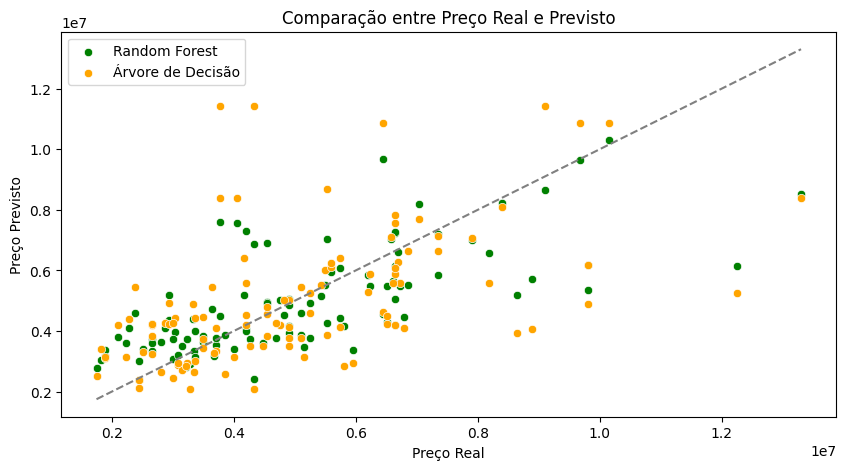

In [ ]:
# 7. Comparar visualmente
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test, y=y_pred_floresta, label="Random Forest", color="green")
sns.scatterplot(x=y_test, y=y_pred_arvore, label="Árvore de Decisão", color="orange")
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--k', color='gray')
plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')
plt.title('Comparação entre Preço Real e Previsto')
plt.legend()
plt.show()

gráfico detalha a performance do seu modelo de previsão, permitindo que você entenda onde ele acerta e erra, e o mais importante, como esse desempenho varia geograficamente, estado por estado. Isso é crucial para identificar se a localização está influenciando o quão bem o modelo pode prever os preços a linha diagonal representa onde o preço previsto é igual ao preço real. Pontos próximos a esta linha indicam previsões precisas.

# **Prever os preços com o modelo**🔧

In [ ]:
# Fazer a previsão com os dados de teste
y_pred = floresta.predict(X_test)

# **📏 Calcular o erro percentual**

In [ ]:
import numpy as np
import pandas as pd

# Criar DataFrame com comparação
df_resultado = X_test.copy()
df_resultado['Preco_Real'] = y_test
df_resultado['Preco_Previsto'] = y_pred
df_resultado['Erro_%'] = ((df_resultado['Preco_Real'] - df_resultado['Preco_Previsto']) / df_resultado['Preco_Previsto']) * 100

# Classificar se está justo, barato ou caro
def classificar_preco(erro):
    if abs(erro) <= 10:
        return 'Justo'
    elif erro > 10:
        return 'Caro'
    else:
        return 'Barato'

df_resultado['Classificacao'] = df_resultado['Erro_%'].apply(classificar_preco)


# **📊 Visualizar os resultados**

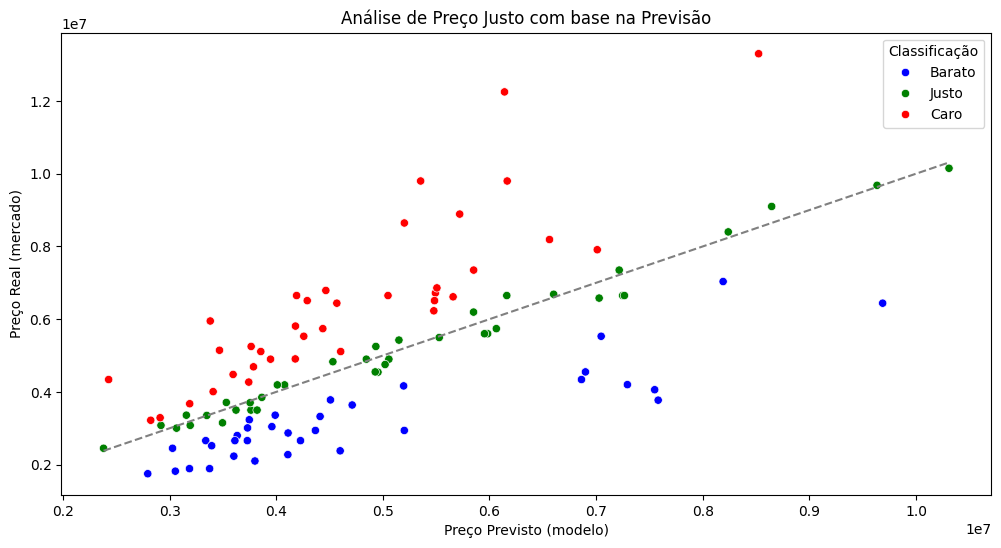

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='Preco_Previsto',
    y='Preco_Real',
    hue='Classificacao',
    data=df_resultado,
    palette={'Justo': 'green', 'Barato': 'blue', 'Caro': 'red'}
)
plt.plot([df_resultado['Preco_Previsto'].min(), df_resultado['Preco_Previsto'].max()],
         [df_resultado['Preco_Previsto'].min(), df_resultado['Preco_Previsto'].max()],
         '--', color='gray')
plt.xlabel('Preço Previsto (modelo)')
plt.ylabel('Preço Real (mercado)')
plt.title('Análise de Preço Justo com base na Previsão')
plt.legend(title='Classificação')
plt.show()


# **✅ Interpretação:**
Pontos verdes (justo): diferença entre previsto e real ≤ 10%
:azul

Pontos azuis (barato): preço real está bem abaixo do previsto (ótima oportunidade!)

Pontos vermelhos (caro): preço real está acima do justo segundo o modelo

#**🏙️ Estados com mais imóveis classificados como Justo ou Barato**

In [ ]:
import plotly.express as px
import pandas as pd

# Filtrar dados classificados como Barato ou Justo
df_filtrado = df_resultado[df_resultado['Classificacao'].isin(['Barato', 'Justo'])]

# Agrupar por estado e classificação
contagem = df_filtrado.groupby(['estado', 'Classificacao']).size().reset_index(name='quantidade')

# Ordenar os estados com mais imóveis
estados_ordenados = (
    contagem.groupby('estado')['quantidade'].sum()
    .sort_values(ascending=False)
    .index.tolist()
)

# Gráfico interativo
fig = px.bar(
    contagem,
    x='estado',
    y='quantidade',
    color='Classificacao',
    text='quantidade',
    category_orders={'estado': estados_ordenados},
    color_discrete_map={'Justo': 'green', 'Barato': 'blue'},
    labels={'quantidade': 'Quantidade de Imóveis'},
    title='Estados com mais imóveis classificados como Justo ou Barato'
)

# Melhorar visual
fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_layout(
    xaxis_title='Estado',
    yaxis_title='Quantidade de Imóveis',
    legend_title='Classificação',
    bargap=0.2
)

fig.show()


O gráfico de dispersão com os pontos coloridos pela classificação ("Justo", "Barato", "Caro"), ele mostra total de imoveis baratos e Justos de acordo com o modelo de classificado.

#**📊 Interpretação dos resultados:**

**MAE (Mean Absolute Error): erro médio entre o preço real e o previsto.**

**R² (coeficiente de determinação): quanto mais próximo de 1, melhor o modelo.**

**O gráfico te mostra se os valores previstos se alinham com os reais (quanto mais próximos da linha diagonal, melhor).**

# 📌 **Conclusão:** Como prever o preço justo
O modelo permite prever o preço justo de uma casa ao considerar fatores como:

Suas características estruturais (área, cômodos, garagem etc.)

Sua localização geográfica (estado e região)

Seu nível de conforto e conveniência (mobilia, aquecimento, estrada)

Esse valor estimado é considerado justo porque é baseado em padrões reais aprendidos com o mercado, com suporte estatístico e preditivo.